# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

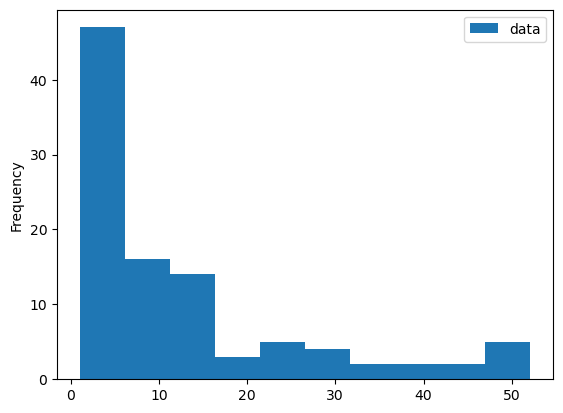

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

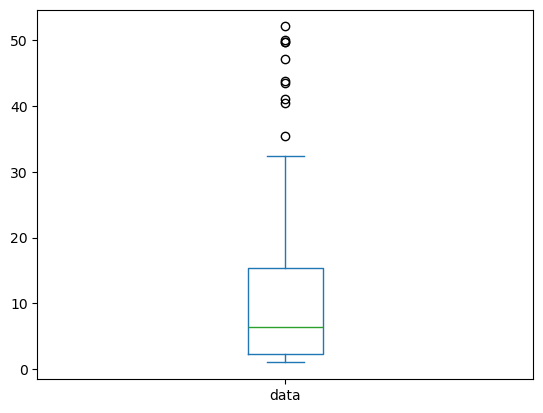

In [5]:
df.plot.box()

| Representation | Pros | Cons |
|----------|----------|----------|
| Histogram  | More common graph, easier to read  | Shape of histogram is distracting from desired point; no title or axes labels  |
| Boxplot  | Shows mean and more expensive prices as clear outliers  | Numeric estimation of this graph is not easily readable (median ~ 6?) Needs clearer visuals (incl. title and labels) |   

Of the two representations, I would choose would be the bot plot for a clearer representation of the difference between the more expensive drug prices vs the mean.    
I would modify the formatting of both the plots to include a title, axes labels, and units (assumed: USD). For the box plot specifically, I would also add a label at the mean (ex., 'Mean price: $10.92') and a few labels at the outliers to more directly compare the prices.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

### Load Data

In [6]:
diabetes_indicators = pd.read_csv('Modified_Datasets/diabetes_indicators.csv')

In [7]:
obesity = pd.read_csv('Modified_Datasets/obesity.csv')

In [8]:
cervical_cancer = pd.read_csv('Modified_Datasets/cervical_cancer.csv')

**Diabetes Indicators**

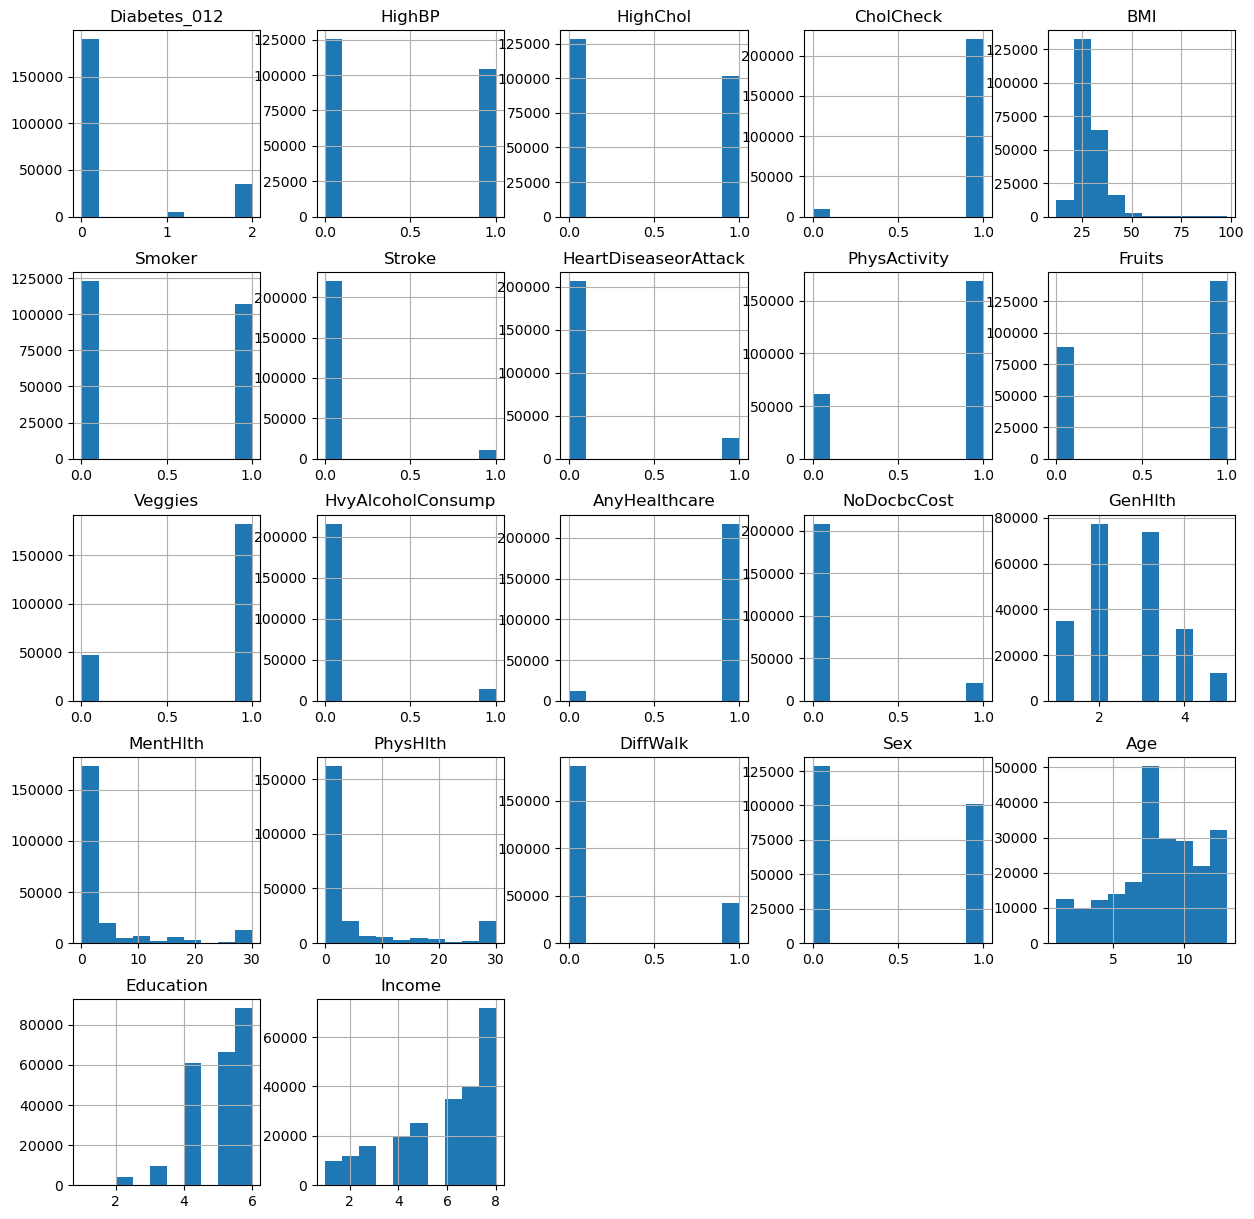

In [9]:
# Histogram

diabetes_indicators.hist(figsize = (15,15))
plt.show()

In [10]:
# Histogram variant

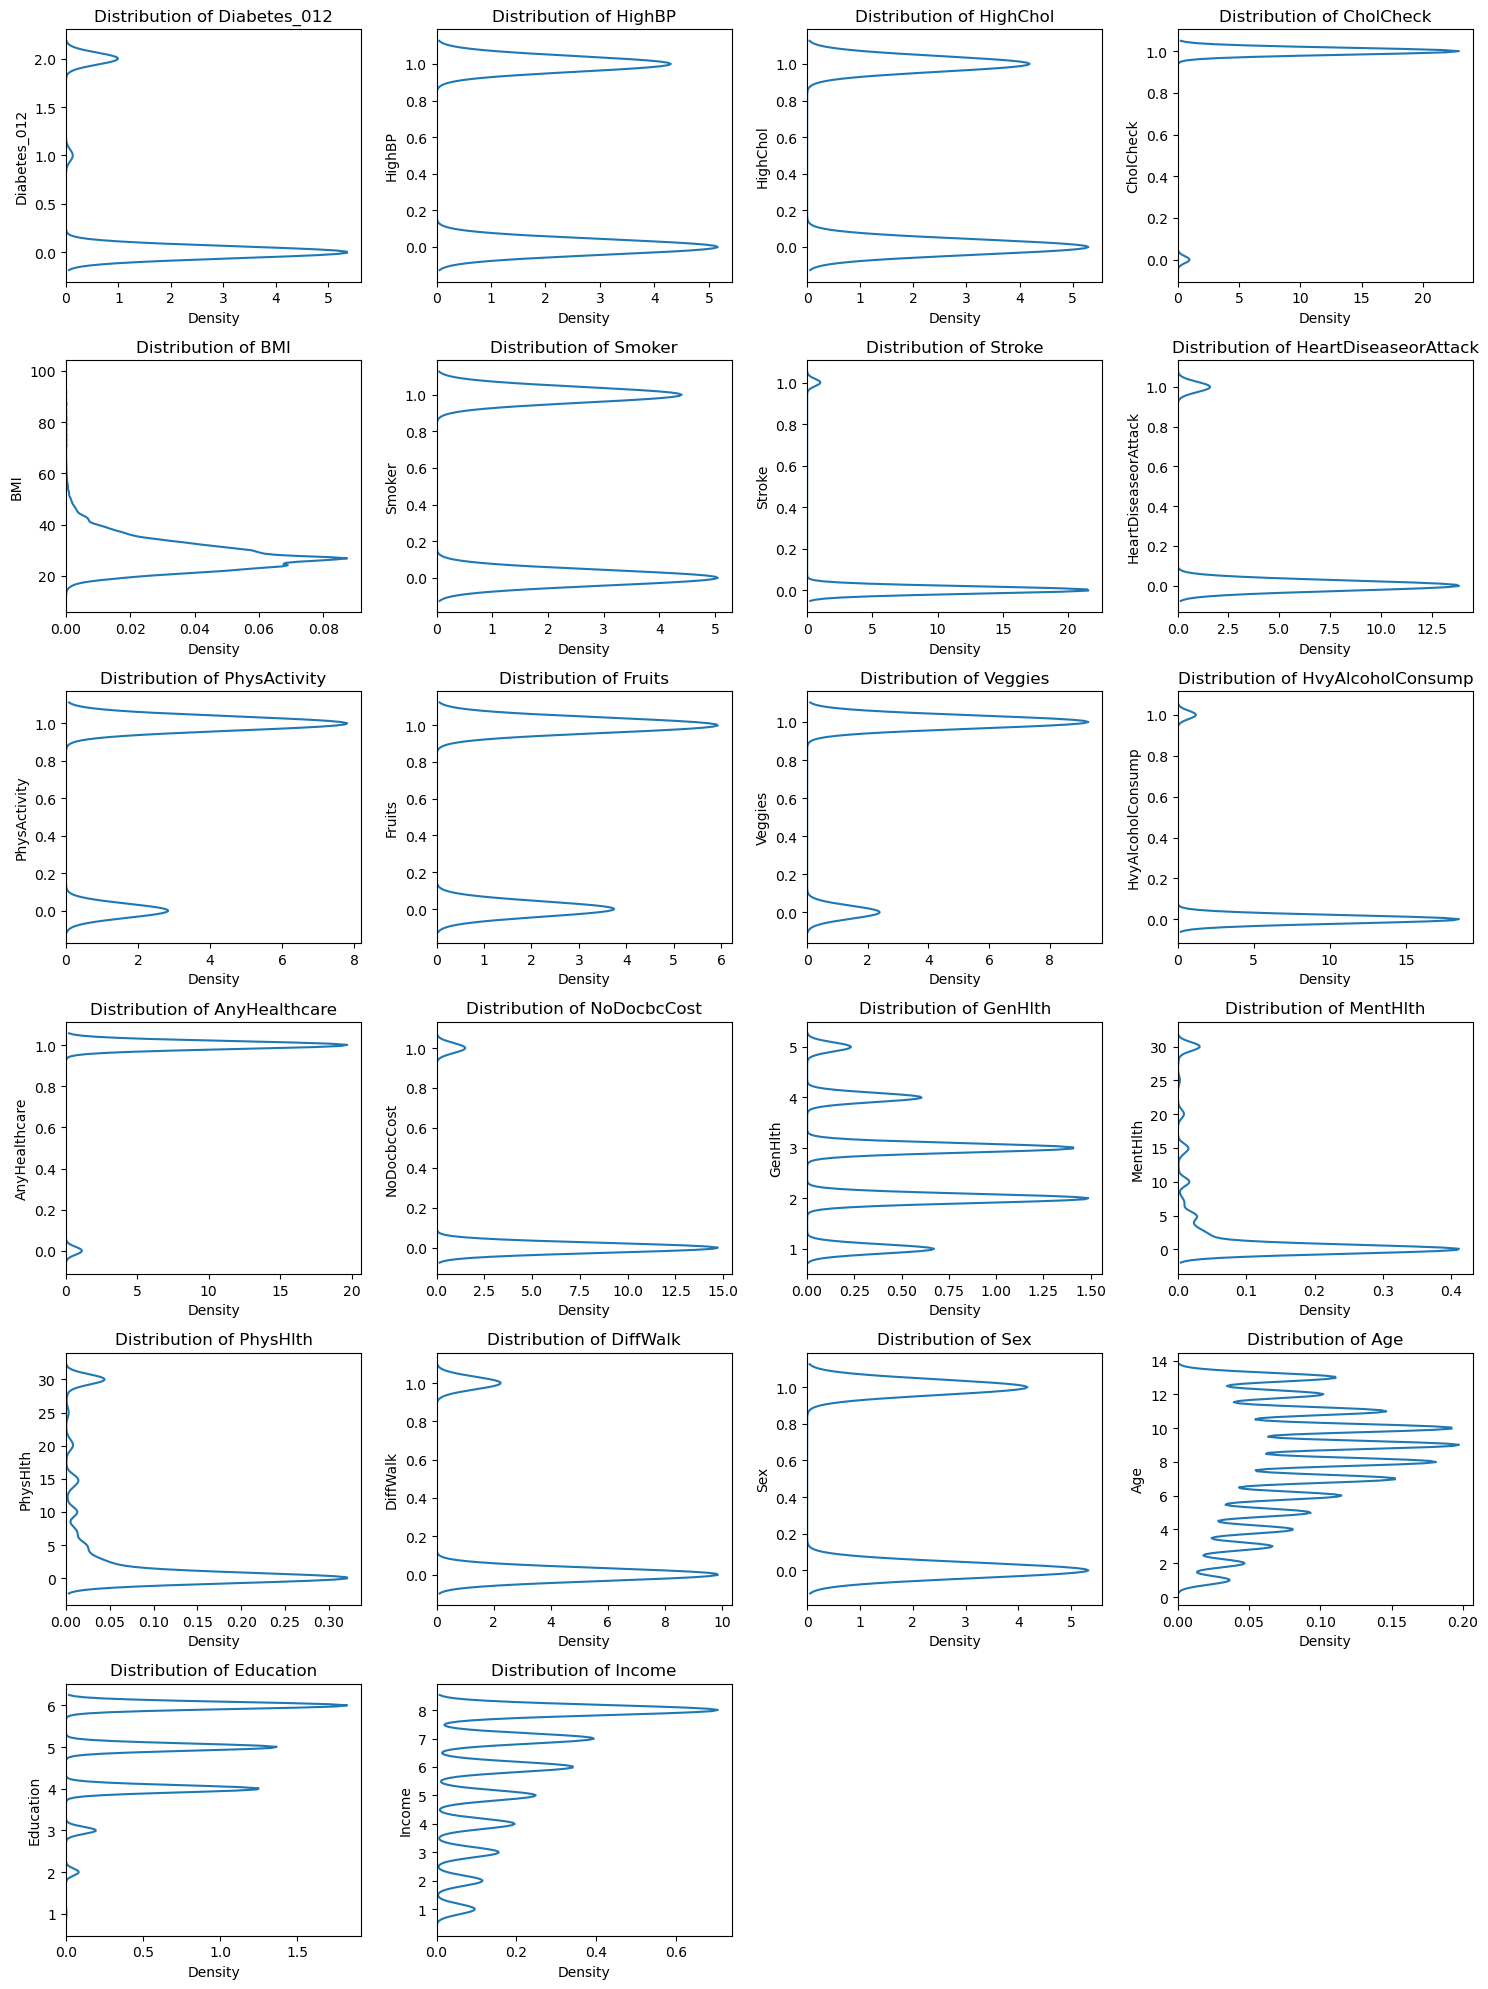

In [11]:
# KDE plot
# Data to plot
numeric_cols = diabetes_indicators.columns

# Set canvas
fig, ax = plt.subplots(nrows = 6, ncols = 4, figsize = (15, 20))
ax = ax.flatten()

# Plot
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=diabetes_indicators, y = col, ax = ax[i])
    ax[i].set_title(f"Distribution of {col}")

# Delete unused plots
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])
    
plt.tight_layout()
plt.show()

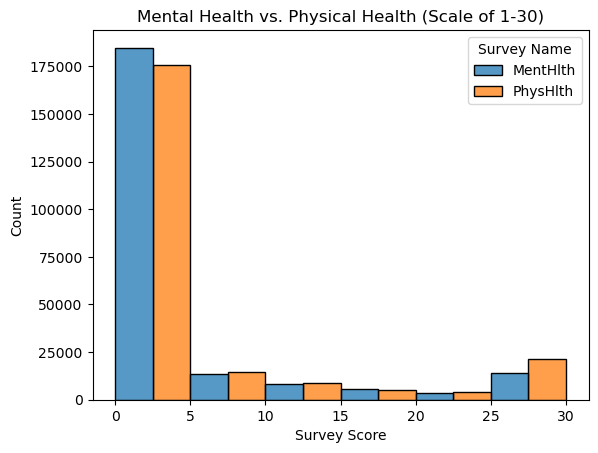

In [12]:
# Grouped histogram

# Plotting specific columns vs all columns due to correlation
data = diabetes_indicators.melt(value_vars = ['MentHlth','PhysHlth'], var_name = 'Survey Name', value_name = 'Survey Score')

sns.histplot(data = data, x = 'Survey Score', hue = 'Survey Name', multiple = 'dodge', binwidth = 5, legend = True)
plt.title('Mental Health vs. Physical Health (Scale of 1-30)')
plt.show()

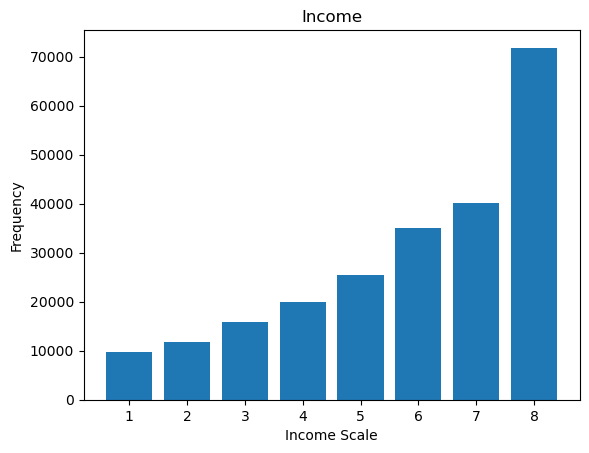

In [13]:
# Bar plot
data = diabetes_indicators['Income'].value_counts().sort_index()
x = data.index
y = data.values
    
plt.bar(x,y)
plt.xlabel('Income Scale')
plt.ylabel('Frequency')
plt.title('Income')
plt.show()

In [14]:
# Mean, median, mode

In [15]:
diabetes_indicators.agg(['mean', 'median'])

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
mean,0.325627,0.454441,0.44176,0.959535,28.68567,0.465661,0.044756,0.103216,0.733355,0.612966,0.794813,0.06071,0.946075,0.09281,2.601151,3.505373,4.675178,0.185507,0.439231,8.086582,4.980568,5.890383
median,0.000000,0.000000,0.00000,1.000000,27.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,0.00000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000


In [16]:
diabetes_indicators.mode()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,9,6,8


**Diabetes Indicators: Conclusions**

Shapes of the distributions vary, from normal to left/right skewed to bimodal.   
No outliers spotted.   
For multiple related histograms: The distributions of mental health and physical health follow the same behavior.   
Min and max values on each histogram vary, from 0/1 (binary) to 1/30 (survey scores), etc.   
Bin sizes affect the histogram by altering readability, in many cases changed bin width for clarity.      
Changing the bin width does reveal different patterns in the data than thinner bin widths due to readability.   

**Obesity**

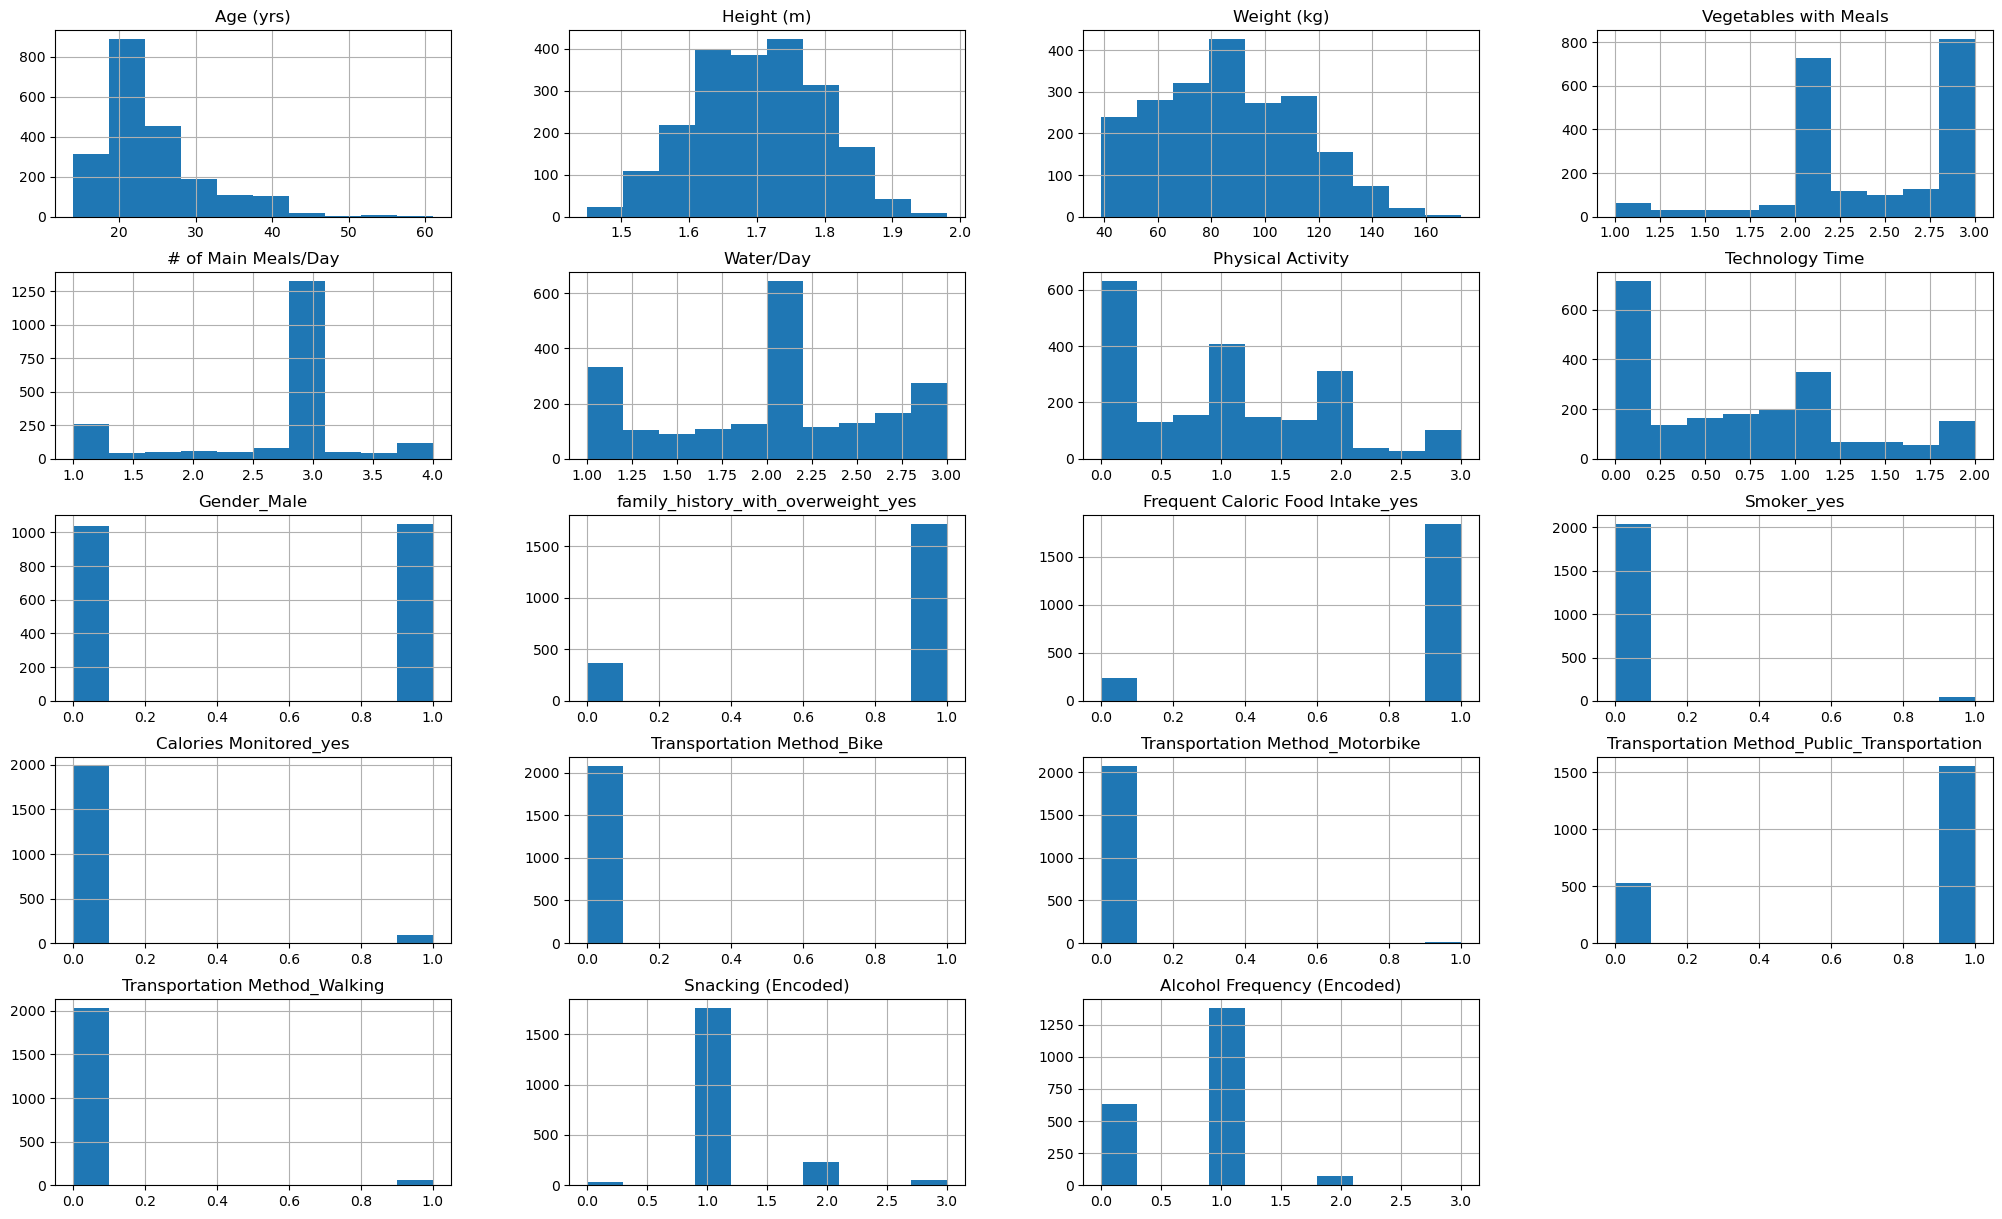

In [17]:
# Histogram

obesity.hist(figsize = (25,15))
plt.show()

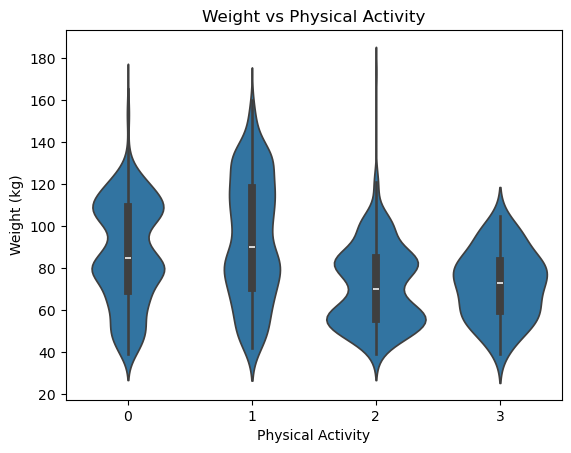

In [18]:
# Histogram variant

# Switching to violin plot for experience
sns.violinplot(data = obesity, x = obesity['Physical Activity'].astype(int), y = obesity['Weight (kg)'].astype(int))
plt.title('Weight vs Physical Activity')
plt.show()

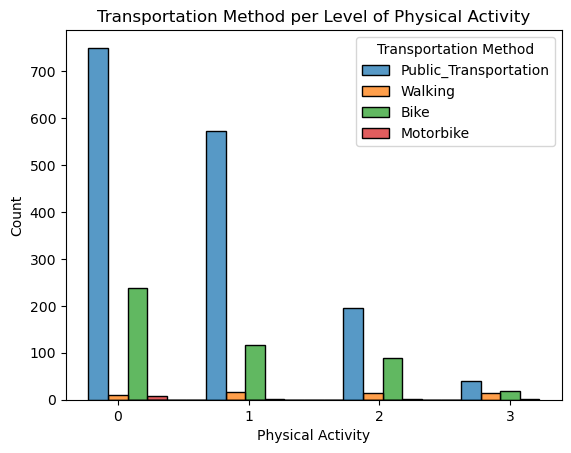

In [19]:
# Grouped histogram

# Reverse one hot encoding 
transportation = obesity
transportation['Transportation Method'] = obesity[['Transportation Method_Bike', 'Transportation Method_Motorbike', 'Transportation Method_Public_Transportation', 'Transportation Method_Walking']].idxmax(axis = 1)
transportation['Transportation Method'] = transportation['Transportation Method'].str.replace('Transportation Method_','')

# Plot
ax = sns.histplot(data = transportation, x = transportation['Physical Activity'].astype(int), hue = 'Transportation Method', multiple = 'dodge', shrink = 4)
ax.set_xticks([0,1,2,3])
plt.title('Transportation Method per Level of Physical Activity')
plt.show()

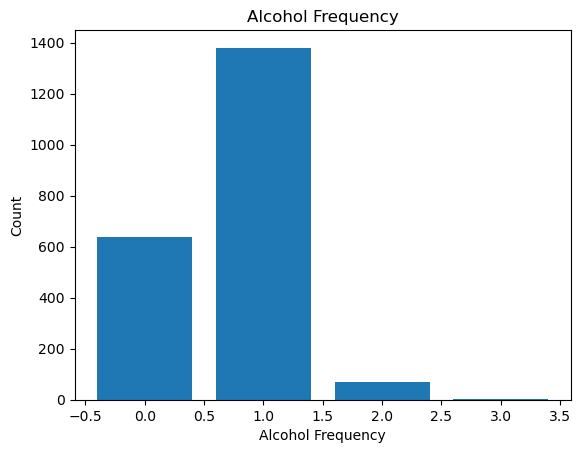

In [20]:
# Bar plot

data = obesity['Alcohol Frequency (Encoded)'].value_counts().sort_index()
x = data.index
y = data.values
    
plt.bar(x,y)
plt.xlabel('Alcohol Frequency')
plt.ylabel('Count')
plt.title('Alcohol Frequency')
plt.show()

In [21]:
# Mean, median, mode

In [22]:
obesity.select_dtypes(include = 'number').agg(['mean', 'median'])

,Age (yrs),Height (m),Weight (kg),Vegetables with Meals,# of Main Meals/Day,Water/Day,Physical Activity,Technology Time,Gender_Male,family_history_with_overweight_yes,Frequent Caloric Food Intake_yes,Smoker_yes,Calories Monitored_yes,Transportation Method_Bike,Transportation Method_Motorbike,Transportation Method_Public_Transportation,Transportation Method_Walking,Snacking (Encoded),Alcohol Frequency (Encoded)
mean,24.353090,1.702674,86.85873,2.421466,2.701179,2.004749,1.012812,0.663035,0.504073,0.825108,0.883565,0.021083,0.045999,0.003354,0.005271,0.746526,0.026354,1.146143,0.729756
median,22.847618,1.701584,83.10110,2.396265,3.000000,2.000000,1.000000,0.630866,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000


In [23]:
obesity.select_dtypes(include = 'number').mode()

,Age (yrs),Height (m),Weight (kg),Vegetables with Meals,# of Main Meals/Day,Water/Day,Physical Activity,Technology Time,Gender_Male,family_history_with_overweight_yes,Frequent Caloric Food Intake_yes,Smoker_yes,Calories Monitored_yes,Transportation Method_Bike,Transportation Method_Motorbike,Transportation Method_Public_Transportation,Transportation Method_Walking,Snacking (Encoded),Alcohol Frequency (Encoded)
0,18.0,1.7,80.0,3.0,3.0,2.0,0.0,0.0,1,1,1,0,0,0,0,1,0,1,1


**Obesity: Conclusions**   
Shape of the distributions are mostly left/right skewed, with one normal distribution.   
No outliers spotted.   
For multiple related histograms: Physical activity is correlated with a lower (and denser) distribution of weight.  
Min and max values on each histogram vary, from 0-1 (binary) to 0-180 (weight), etc.  
Bin sizes can improve histogram visibility.    
Changing the bin width does reveal different patterns in the data by more clearly illustrating which variables have a continuous distribution, and which do not.   

**Cervical Cancer**

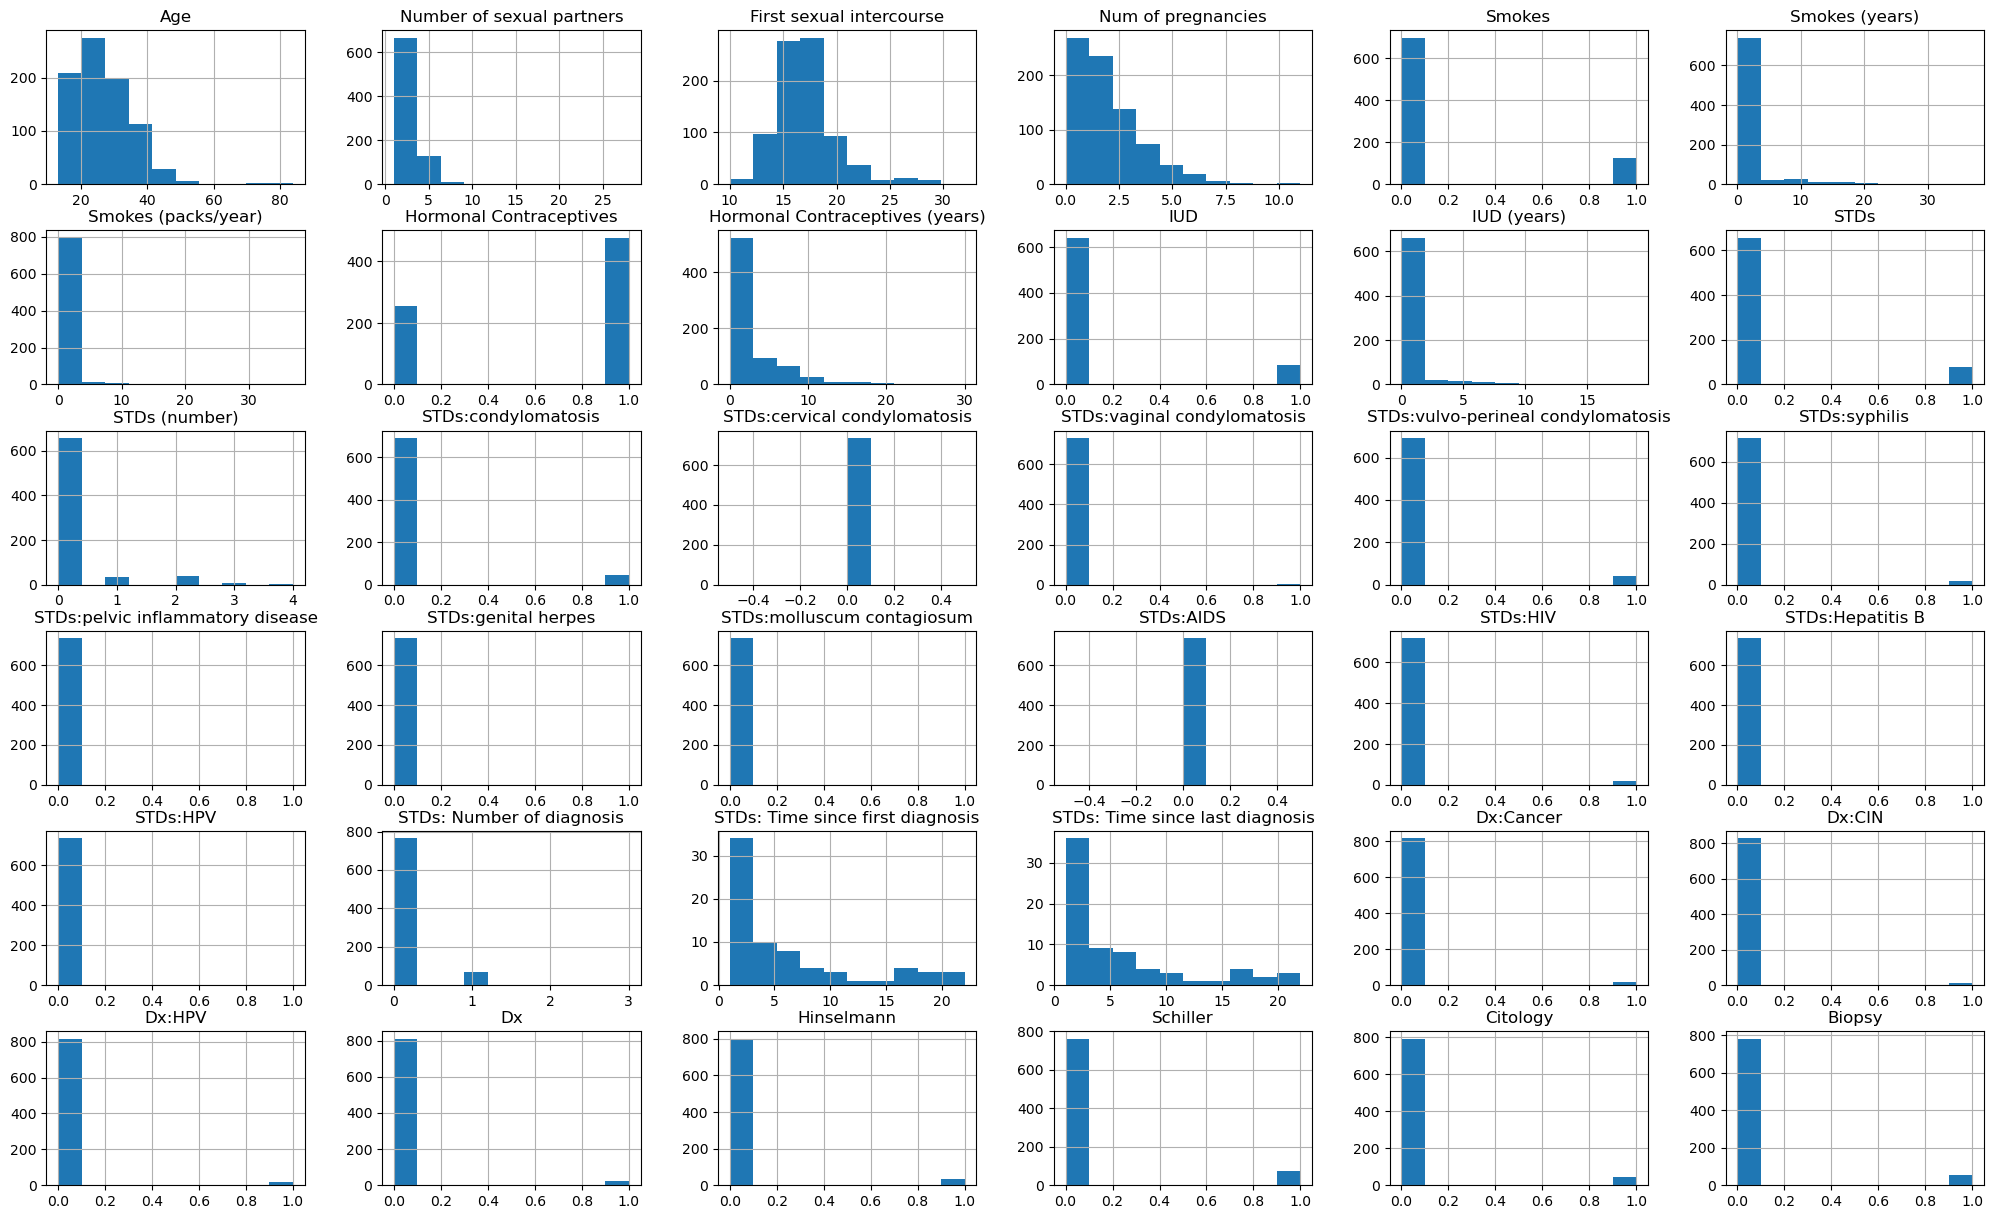

In [24]:
# Histogram

cervical_cancer.hist(figsize = (25,15))
plt.show()

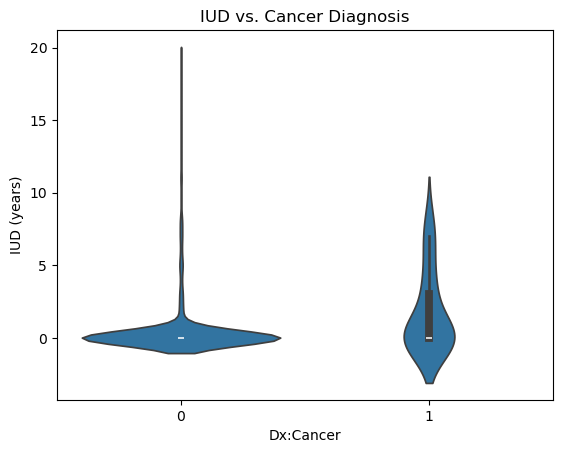

In [25]:
# Histogram variant

sns.violinplot(data = cervical_cancer, x = cervical_cancer['Dx:Cancer'].astype(int), y = cervical_cancer['IUD (years)'])
plt.title('IUD vs. Cancer Diagnosis')
plt.show()

C:\Users\golde\AppData\Local\Temp\ipykernel_40360\1824494922.py:10: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  'STDs:Hepatitis B', 'STDs:HPV']].idxmax(axis = 1)


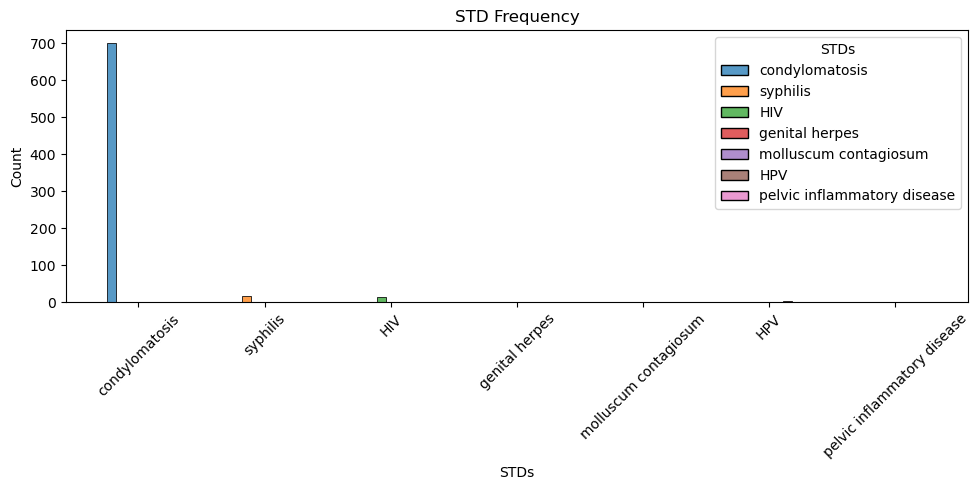

In [26]:
# Grouped histogram

# Reverse one hot encoding 
copy = cervical_cancer.copy()
copy['STDs'] = cervical_cancer[['STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
        'STDs:Hepatitis B', 'STDs:HPV']].idxmax(axis = 1)
copy['STDs'] = cervical_cancer['STDs'].str.replace('STDs:','')

# Plot
plt.figure(figsize=(10, 5))
ax = sns.histplot(data = copy, x = 'STDs', hue = 'STDs', multiple = 'dodge', shrink = 0.5)
plt.title('STD Frequency')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

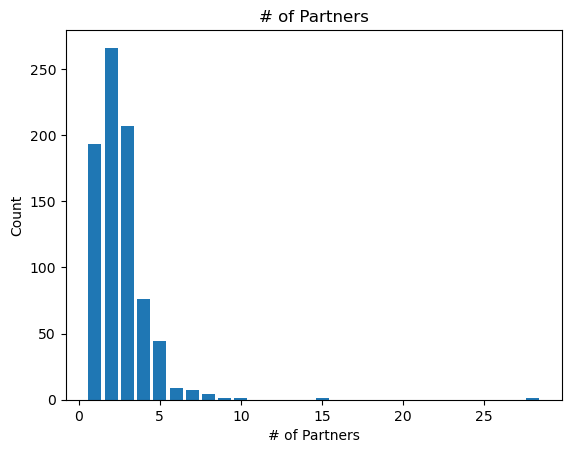

In [27]:
# Bar plot

data = cervical_cancer['Number of sexual partners'].value_counts().sort_index()
x = data.index
y = data.values
    
plt.bar(x,y)
plt.xlabel('# of Partners')
plt.ylabel('Count')
plt.title('# of Partners')
plt.show()

In [28]:
# Mean, median, mode

In [29]:
cervical_cancer.select_dtypes(include = 'number').agg(['mean', 'median'])

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
mean,27.023952,2.551852,17.020531,2.304236,0.149635,1.25385,0.465823,0.651639,2.302916,0.114799,0.527621,0.180952,0.059864,0.0,0.005442,0.058503,0.02449,0.001361,0.001361,0.001361,0.0,0.02449,0.001361,0.002721,0.08982,6.140845,5.816901,0.021557,0.010778,0.021557,0.028743,0.041916,0.087425,0.051497,0.064671
median,26.000000,2.000000,17.000000,2.000000,0.000000,0.00000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.00000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [30]:
cervical_cancer.select_dtypes(include = 'number').mode()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,23,2.0,15.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0,1.0,0,0,0,0,0,0,0,0


**Cervical Cancer: Conclusions**   
Shapes of the distributions are primarily right skewed.   
No outliers spotted.   
For multiple related histograms: the time since the first diagnosis and the time since the last diagnosis have the same distribution shape. 
Min and max values on each histogram vary, with 0/1 (binary) to 0-90 (age).   
Bin sizes affect the histogram by illustrating whether variables are continuous and/or how to portray them.   
Changing the bin width does reveal different patterns in the data.   

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

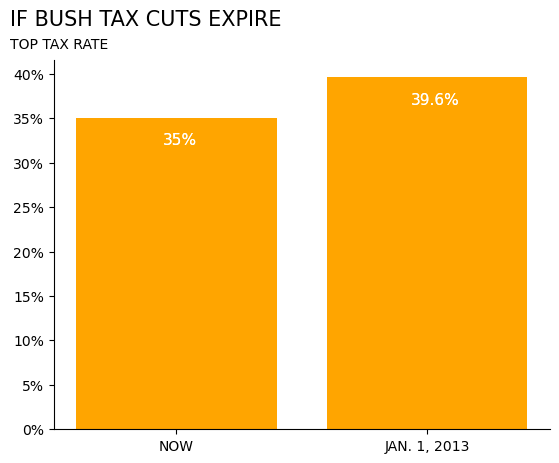

In [31]:
x = ['NOW', 'JAN. 1, 2013']
y = [35, 39.6]

fig, ax = plt.subplots()
bars = plt.bar(x, y, color = 'orange')
plt.title('IF BUSH TAX CUTS EXPIRE', fontsize = 15, x = 0.46, y = 1.07, ha = 'right')
ax.text(0.11, 1.03, 'TOP TAX RATE', fontsize = 10, transform = ax.transAxes, ha = 'right')

for bar in bars:
    ax.text(0.22, 0.77, '35%', fontsize = 11, transform = ax.transAxes, color = 'white')
    ax.text(0.72, 0.88, '39.6%', fontsize = 11, transform = ax.transAxes, color = 'white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

plt.show()